In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq signal (sumprom) for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

# Clustal Omega sequence similarity matrix paths
dbd_similarity_filepath = "metadata/dbd_similarity_clustalo.pim"
nondbd_similarity_filepath = "metadata/nondbd_similarity_clustalo.pim"

## Imports

In [3]:
import numpy as np
import pandas as pd

from scipy.stats import zscore

import glob

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1": FOXK1_WT, "GABPA": GABPA_WT, "SOX10": SOX10_WT, "HXD10": HXD10_WT, "GATA1": GATA1_WT, "BATF3": BATF3_WT, "HEY1": HEY1_WT, "NFAC4": NFAC4_WT, "TF2LY": TF2LY_WT, "PO3F2": PO3F2_WT}

In [5]:
supmrom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in supmrom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z=sumprom.apply(zscore)
sumprom_z_corr = sumprom_z.corr()

## Load Percent Identity Matrixes (.pim files from ClustalO)
https://www.ebi.ac.uk/jdispatcher/msa/clustalo

In [6]:
def read_pim(filepath):
    names = []
    matrix = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            # Skip comments or empty lines
            if not line or line.startswith("#"):
                continue
            # Split at colon to remove index
            left, right = line.split(":", 1)
            # First token after colon is the name
            parts = right.strip().split()
            name = parts[0]
            values = parts[1:]
            # Convert values to float (handle -nan)
            values = [float(v) if v.lower() != "-nan" else np.nan for v in values]
            names.append(name)
            matrix.append(values)
    df = pd.DataFrame(matrix, index=names, columns=names)
    return df

dbd_similarity = read_pim(dbd_similarity_filepath)
nondbd_similarity = read_pim(nondbd_similarity_filepath)

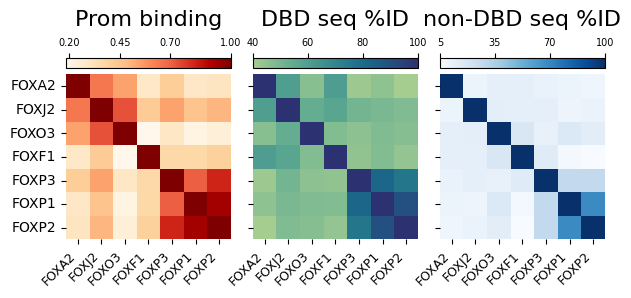

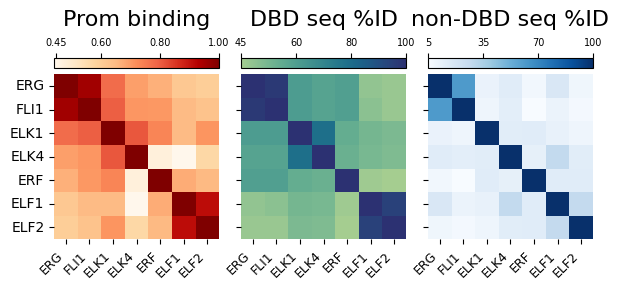

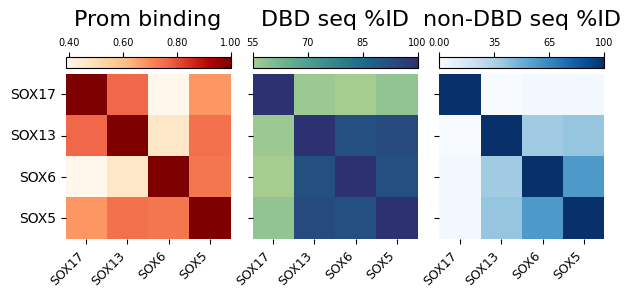

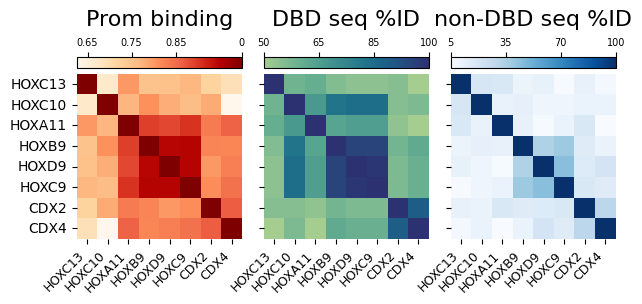

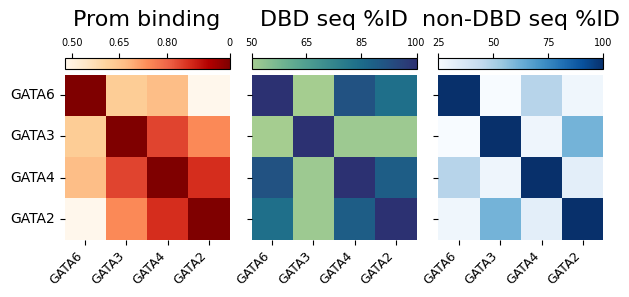

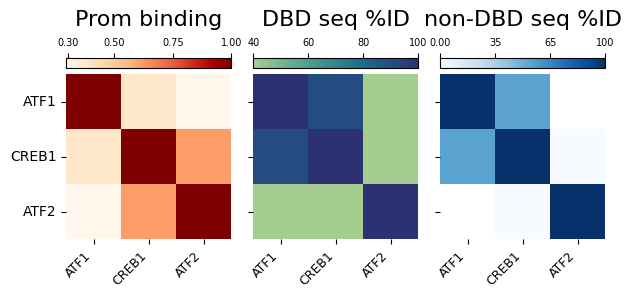

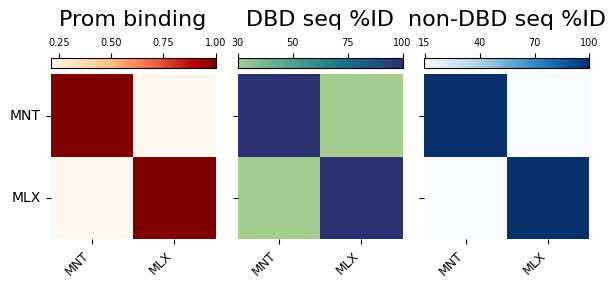

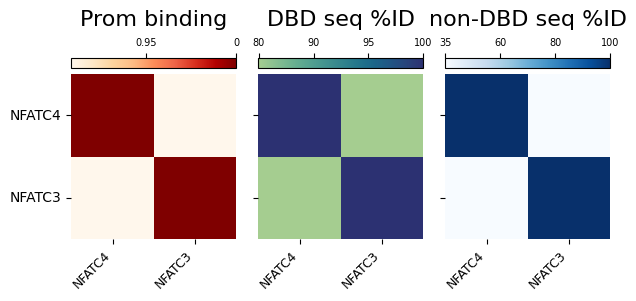

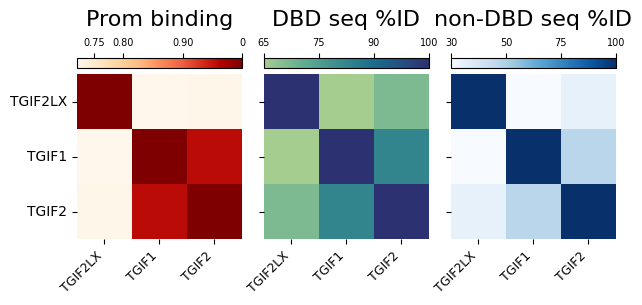

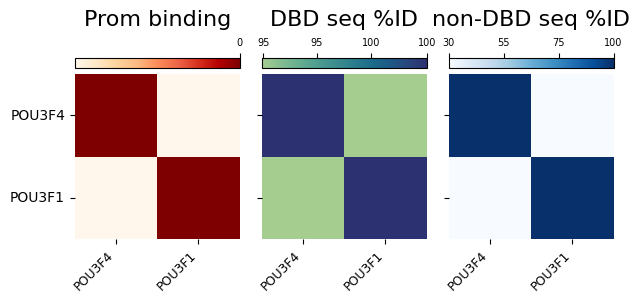

In [7]:
for fam, members in dbd_fam_dict.items():

    members = [s for s in members
               if s in sumprom_z_corr.index
               and s in dbd_similarity.index
               and s in nondbd_similarity.index]

    if len(members) < 2:
        continue

    sub_bind = sumprom_z_corr.loc[members, members]
    dist = 1.0 - sub_bind.values
    Z = linkage(squareform(dist, checks=False), method="average")
    ordered = [members[i] for i in leaves_list(Z)]

    mats = [df.loc[ordered, ordered].rename(index=lambda x: "ERF" if x == "ERF1" else x,
                                        columns=lambda x: "ERF" if x == "ERF1" else x)
        for df in [sumprom_z_corr, dbd_similarity, nondbd_similarity]]

    titles = ["Prom binding", "DBD seq %ID", "non-DBD seq %ID"]
    cmaps = ["OrRd", "crest", "Blues"]


    fig, axes = plt.subplots(1, 3, figsize=(6.5, 3.0), sharex=True, sharey=True)

    fig.subplots_adjust(left=0.12, right=0.98,
                        bottom=0.30, top=0.85,
                        wspace=0.01)

    heatmaps = []

    for i, (ax, mat, title, cmap) in enumerate(zip(axes, mats, titles, cmaps)):

        hm = sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            cbar=False,
            square=True
        )
        heatmaps.append(hm)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(title, fontsize=16, pad=35)
        ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=9)

        if i == 0:
            ax.set_yticks(np.arange(len(mat.index)) + 0.5)
            ax.set_yticklabels(mat.index, rotation=0, fontsize=10)
            ax.tick_params(axis="y", labelleft=True)

    # ---- top colorbars ----
    for ax, hm in zip(axes, heatmaps):

        pos = ax.get_position()
        cax = fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.035])

        mappable = hm.collections[0]
        cb = plt.colorbar(mappable, cax=cax, orientation="horizontal")

        cb.ax.xaxis.set_ticks_position("top")
        cb.ax.xaxis.set_label_position("top")
        cb.ax.tick_params(labeltop=True, labelbottom=False, labelsize=7)

        vmin = mappable.norm.vmin
        vmax = mappable.norm.vmax

        start = np.ceil(vmin / 0.05) * 0.05
        ticks = np.arange(start, vmax + 1e-6, 0.05)

        if len(ticks) > 5:
            idx = np.linspace(0, len(ticks) - 1, 4, dtype=int)
            ticks = ticks[idx]

        # ---- formatting rules ----
        formatted = []
        for t in ticks:
            if t >= 1:
                t = int(np.round(t / 5) * 5)  # ensure divisible by 5
                formatted.append(f"{int(t)}")
            else:
                formatted.append(f"{t:.2f}")

        cb.set_ticks(ticks)
        cb.set_ticklabels(formatted)

    plt.show()
